## Exercise 05: Boxplot (lag before deadlines)

Goal:
- Visualize not just averages, but **spread/variance/outliers** of `diff` values.
- Compare **control vs test** separately for:
  - after the newsfeed
  - before the newsfeed

We will:
1) Load `ab-test.csv`.
2) Split by `time` (before/after) and `group` (control/test).
3) Draw two boxplots (subplots): left = after, right = before.

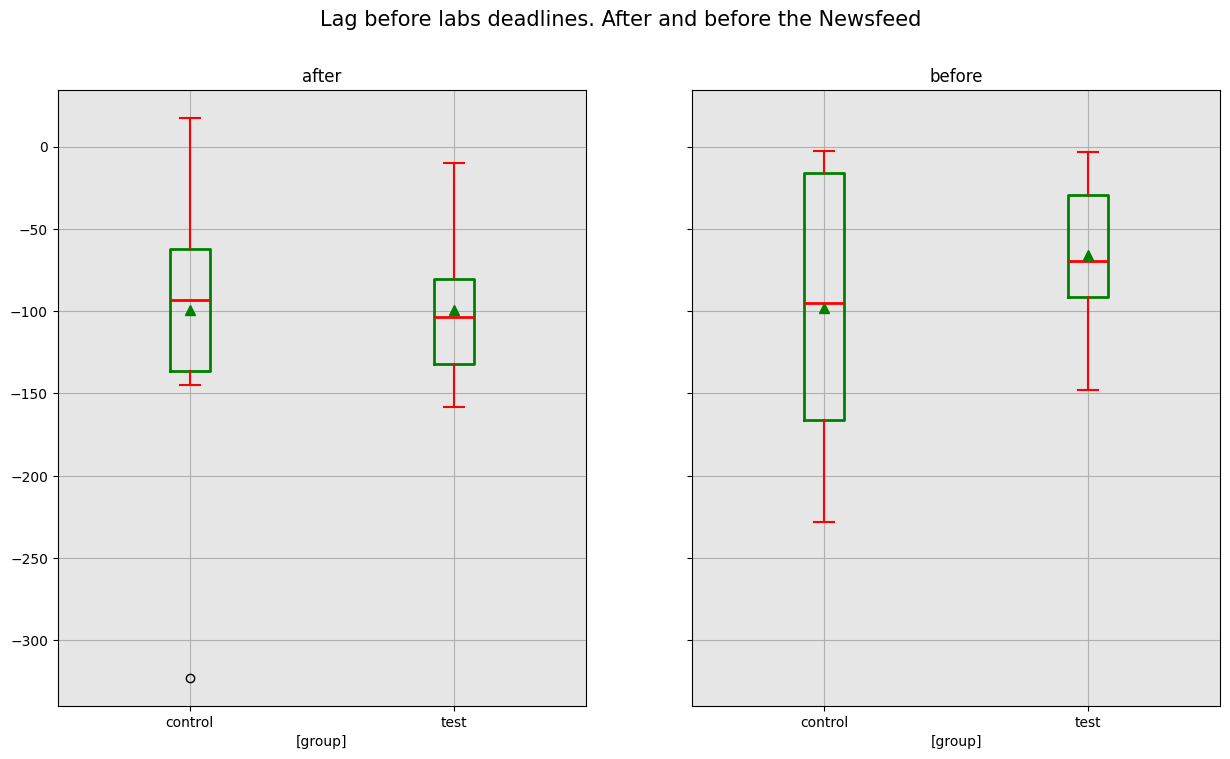

In [1]:
import pandas as pd
import sqlite3  # allowed, even if unused here
import matplotlib.pyplot as plt

# 1) Load CSV
df = pd.read_csv("../data/ab-test.csv")

# 2) Ensure numeric diff
df["diff"] = pd.to_numeric(df["diff"], errors="coerce")
df = df.dropna(subset=["diff"])

# 3) Prepare data in the exact order: control then test
def data_for(time_value):
    sub = df[df["time"] == time_value]
    control = sub[sub["group"] == "control"]["diff"].tolist()
    test = sub[sub["group"] == "test"]["diff"].tolist()
    return [control, test]

data_after = data_for("after")
data_before = data_for("before")

# 4) Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
fig.suptitle("Lag before labs deadlines. After and before the Newsfeed", fontsize=15)

# Style to match the example (green box, red whiskers/median, mean triangle)
boxprops = dict(color="green", linewidth=2)
whiskerprops = dict(color="red", linewidth=1.5)
capprops = dict(color="red", linewidth=1.5)
medianprops = dict(color="red", linewidth=2)
meanprops = dict(marker="^", markerfacecolor="green", markeredgecolor="green", markersize=7)

for ax, title, data in [(axes[0], "after", data_after), (axes[1], "before", data_before)]:
    ax.set_facecolor("#E6E6E6")
    ax.grid(True)
    ax.boxplot(
        data,
        labels=["control", "test"],
        showmeans=True,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops,
        meanprops=meanprops
    )
    ax.set_title(title)
    ax.set_xlabel("[group]")

plt.show()